# Beginning - Calculate Electric Field Properties for a Step Index Fibre

We begin the project by calculating the electric field properties of the wave injected into the fibre. After that, we use the electric field profile to calculate the diffraction limited profile of the electric field. 

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi


## 1. Defind the fibre's core diameter and numerical aperature used for NIR

We will use a normalised frequency value provided from the approximated wavelength, fibre core radius and numerical aperature to "solve" the Bessel function which are defined to be proportional to the electric field as a function of radius, $E_{lm}(r)$. 

In [ ]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

In [11]:
# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [13]:
# Approximate number of modes that the fibre can support using the V-number
M = V**2 / 4
print(f"Approximate number of modes that the fibre can support: {M:.2f}")

Approximate number of modes that the fibre can support: 1.10


## 2. Find the electric field profile by solving the characteristic equation computationally (or graphically)

Using the normalised frequency, we want to solve the characteristic equation (equivalent to the condition for a light wave propagating down a waveguide to remain in phase with itself). By solving the characteristic equation, we will drive the Bessel function used to represent the electric field inside the core and in the cladding. 

Characteristic equation: 
$X \frac{J_{l+1}(X)}{J_l(X)} = \pm Y \frac{K_{l+1}(Y)}{K_l(Y)}$

The relation: 
$X^2 + Y^2 = V^2 $

### Theory: Applying Bessel Functions here

For a step-index fibre, when we solve the wave equation in cylindrical coordinates, the radial part of the solution is no longer in the form of sine or cosine. 
Because we have approximated the electromagnetic field to be transverse as the light travelling down the fibre is close to the optical axis, and we have a weakly guiding fibre where the confinement of the field to the core is not strong. 

The field profile becomes:
 - Proportional to the ordinary Bessel function $J_l$ inside the fibre
 - Proportional to the modified Bessel function $K_l$ in the cladding

In [17]:
# jv?


For l=0, the characteristic equation becomes:

$X \frac{J_{1}(X)}{J_0(X)} = \pm Y \frac{K_{1}(Y)}{K_0(Y)}$

Find the root where $X \frac{J_{1}(X)}{J_0(X)} - Y \frac{K_{1}(Y)}{K_0(Y)} = 0$


In [ ]:
# Define the range of x values for plotting the Bessel functions
X = np.linspace(0, V, 1000)
Y = np.sqrt(V**2 - X**2)

# Note: jv(v, z) represent first kind of Bessel function of order v and argument z is the input value, z = X * r / a 
LHS = X * jv(1, X) / jv(0, X)
RHS = Y * kv(1, Y) / kv(0, Y)



/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_12408/2311735680.py:7: RuntimeWarning: invalid value encountered in multiply
  RHS = Y * kv(1, Y) / kv(0, Y)


<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_12408/2814211851.py:3: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(X, LHS, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_12408/2814211851.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X, RHS, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')


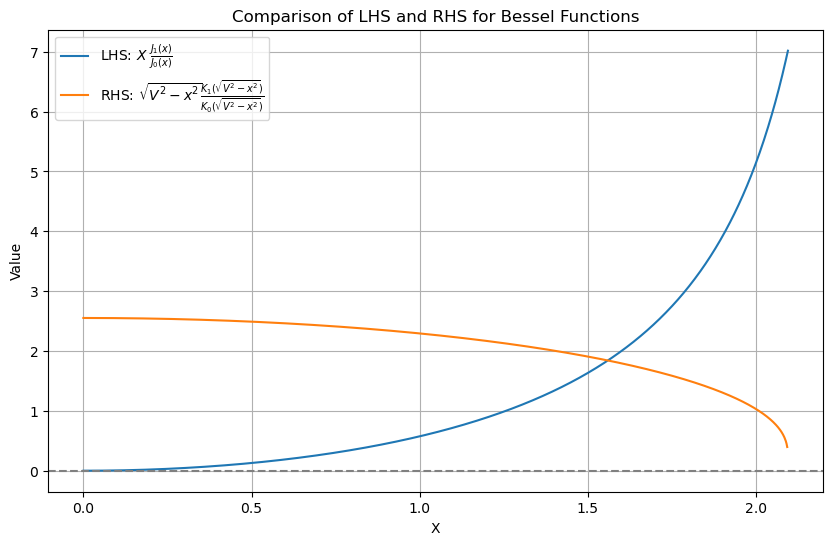

In [25]:
# Plot the left-hand side and right-hand side of the equation
plt.figure(figsize=(10, 6))
plt.plot(X, LHS, label='LHS: $X\ \\frac{J_1(x)}{J_0(x)}$')
plt.plot(X, RHS, label='RHS: $\sqrt{V^2 - x^2} \\frac{K_1(\sqrt{V^2 - x^2})}{K_0(\sqrt{V^2 - x^2})}$')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Comparison of LHS and RHS for Bessel Functions')
plt.xlabel('X')
plt.ylabel('Value')
plt.legend()
plt.grid()

In [ ]:
# Optional: difference function
diff = LHS - RHS

# --------------------------
# Find approximate intersection(s)
# --------------------------
roots = []
for i in range(len(X) - 1):
    if np.isfinite(diff[i]) and np.isfinite(diff[i+1]):
        # At X=0, LHS is smaller than RHS, so we look for sign changes in the product between the difference between LFH and RHS at consecutive points to find intersections
        if diff[i] * diff[i+1] < 0:
            roots.append((X[i] + X[i+1]) / 2)

print("Approximate intersections near X =", roots)

Approximate intersections near X = [np.float64(1.5587415001294707)]


In [ ]:
from scipy.optimize import brentq
# The Brent's method is a root-finding algorithm that combines the bisection method, the secant method, and inverse quadratic interpolation. 
# https://en.wikipedia.org/wiki/Brent%27s_method
# It is designed to find roots of a continuous function within a specified interval where the function changes sign. The method is efficient and robust, making it suitable for finding roots of nonlinear equations.
def f(X, V):
    Y = np.sqrt(V**2 - X**2)
    lhs = X * jv(1, X) / jv(0, X)
    rhs = Y * kv(1, Y) / kv(0, Y)
    return lhs - rhs

# example bracket chosen after inspecting the plot
X_root = brentq(f, 1.0, 2.0, args=(V,))
Y_root = np.sqrt(V**2 - X_root**2)

print("X root =", X_root)
print("Y root =", Y_root)

X root = 1.5590595758091075
Y root = 1.3985078062014993


Now since: 
$ X = k_T a$, 
$ Y = \gamma a$

We can model the electric field profile as a (normalised) function of the Bessel Functions: 

$$
E_{lm}(r) \propto 
\begin{cases}
J_l(k_{T_m} r), & r \le a \\
K_l(\gamma_m r), & r > a
\end{cases}
$$


$$
E_{lm}(r) \propto 
\begin{cases}
J_l(\frac{Xr}{a}), & r \le a \\
K_l(\frac{Yr}{a}), & r > a
\end{cases}
$$

Let $\rho = r/a$ be the normalised, so r/a≤1 is inside the core and r/a>1 is inside the cladding, r/a=0 is the fibre centre

$$
E(\rho)=
\begin{cases}
A\,J_0(X\rho), & \rho \le 1 \\
C\,K_0(Y\rho), & \rho > 1
\end{cases}
$$

At the core--cladding boundary, $\rho=1$, the field must be continuous, so

$$
A\,J_0(X)=C\,K_0(Y).
$$

Hence,

$$
C = A\,\frac{J_0(X)}{K_0(Y)}.
$$

Substituting this into the cladding solution gives

$$
E(\rho)=
\begin{cases}
A\,J_0(X\rho), & \rho \le 1 \\
A\,\dfrac{J_0(X)}{K_0(Y)}\,K_0(Y\rho), & \rho > 1.
\end{cases}
$$

Since we are only interested in the shape of the mode profile, we can choose the overall amplitude arbitrarily and set

$$
A=1.
$$

Therefore, the normalized field profile becomes

$$
E(\rho) =
\begin{cases}
J_0(X\rho), & \rho \le 1 \\
\dfrac{J_0(X)}{K_0(Y)} \, K_0(Y\rho), & \rho > 1
\end{cases}
$$

This piecewise expression represents the radial electric field profile of the fundamental mode in a step-index fibre, written in terms of the normalized radius $\rho = r/a$.

Inside the core ($\rho \le 1$), the solution is given by the ordinary Bessel function $J_0(X\rho)$, which describes an oscillatory field distribution. This arises from solving the wave equation in cylindrical coordinates where the field remains finite at the centre.

Outside the core ($\rho > 1$), the solution is given by the modified Bessel function $K_0(Y\rho)$, which decays exponentially. This represents the evanescent field in the cladding, where light is no longer propagating but instead decays away from the core.

The factor $\dfrac{J_0(X)}{K_0(Y)}$ ensures continuity of the electric field at the core–cladding boundary ($\rho = 1$). Without this scaling, the two solutions would not match at the boundary, leading to an unphysical discontinuity in the field.

In the code, this is implemented by:
- evaluating $J_0(X\rho)$ for $\rho \le 1$ (core region),
- evaluating $K_0(Y\rho)$ for $\rho > 1$ (cladding region),
- multiplying the cladding solution by the matching factor $\dfrac{J_0(X)}{K_0(Y)}$,
- combining both regions using boolean masks to construct the full piecewise field.

The resulting field is then normalized and squared to obtain the intensity profile.

In [31]:
# Step 1- Create the radius array for plotting the electric field distribution
rho = np.linspace(0, 3, 1000) # From 0 to 3 times the core radius

# Step 2 - Create an array of zeros with the same shape as rho to store the electric field values
E = np.zeros_like(rho)

# Step 3 - Set the condition as the boundary between core and cladding, this helps to create a piecewise function for the electric field distribution
core = rho <= 1
cladding = rho > 1

# Step 4 - Compute the electric field in the core region (rho <= 1) using the ordinary Bessel function J0.
# E[core] uses conditional (boolean) assignment directly: values are assigned only where the condition is satisfied, allowing us to implement the piecewise solution of the wave equation without using loops.
# Physically, this corresponds to applying the core solution E(rho) = J0(X*rho) only inside the fibre core.

E[core] = jv(0, X_root * rho[core]) # Setting A = 1, multiplied by te Bessel function of zeroth order and ratio rho inside the core

# Step 5 - Set the matching factor at the boundary (rho=1) as J0(X) / K0(Y), this makes the cladding field connect smoothly
match_factor = jv(0,X) / kv(0,Y) 

# Step 6 - Compute the electric field in the cladding region (rho > 1) using the modified Bessel function K0, multiplied by the matching factor to ensure continuity at the boundary
E[cladding] = match_factor * kv(0, Y_root * rho[cladding])

# Step 7 - Normalise the electric field distribution so that the maximum value is 1, this allows us to compare the relative field strength across the fibre cross-section
E_norm = E / np.max(abs(E)) 

# Step 8 - We also compute the intensity profile of the electric field, such that I represents the intensity profile and E represents the field amplitude. 
I = np.abs(E_norm)**2


Text(0.5, 1.0, 'Single mode step-index fibre profile')

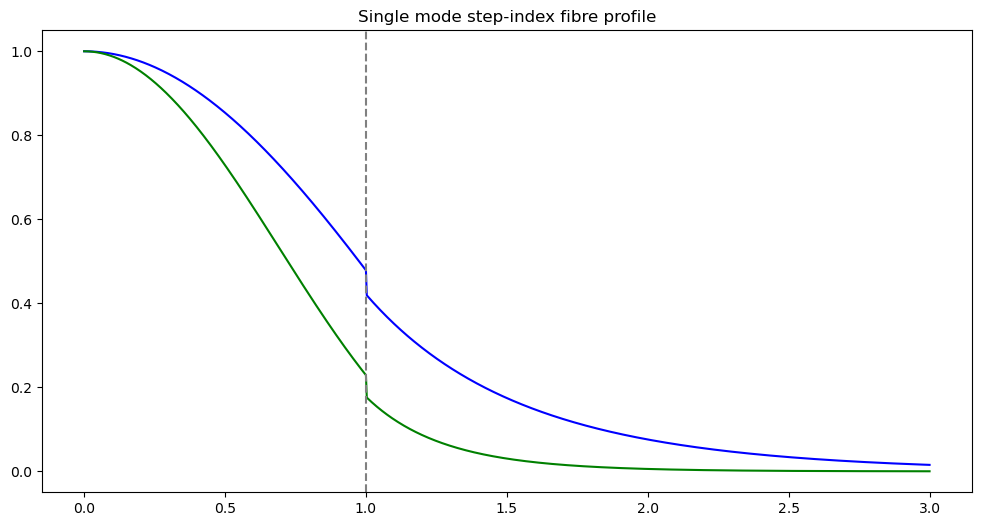

In [ ]:
# Plot the normalised electric field distribution and the intensity profile
plt.figure(figsize=(12, 6))
plt.plot(rho, E_norm, label = 'Normalised field amplitude', color='blue')
plt.plot(rho, I, label = 'intensity profile', color='green')
plt.axvline(1, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.title("Single mode step-index fibre profile")
plt.xlabel('Radius normalised to core radius (rho = r/a)')
plt.ylabel('Normalised Amplitude')
plt.legend()
plt.show()